In [1]:
library(WGCNA)
library(clusterProfiler)
library(ggplot2)

Loading required package: dynamicTreeCut

Loading required package: fastcluster


Attaching package: ‘fastcluster’


The following object is masked from ‘package:stats’:

    hclust





Attaching package: ‘WGCNA’


The following object is masked from ‘package:stats’:

    cor


clusterProfiler v4.18.4 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu, Li-Gen Wang, Yanyan Han and Qing-Yu He.
clusterProfiler: an R package for comparing biological themes among
gene clusters. OMICS: A Journal of Integrative Biology. 2012,
16(5):284-287


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter




In [2]:
setwd("/home/seba/github_repos/crc_weighted_network/cohort_white")

In [3]:
# Intra module preservation on white cohort
datExpr_tumor <- readRDS("rna_tumor/datExpr_clean.rds")
datExpr_normal <- readRDS("rna_normal/datExpr_clean.rds")

In [4]:
commonGenes <- intersect(colnames(datExpr_tumor), colnames(datExpr_normal))

datExpr_tumor  <- datExpr_tumor[, commonGenes, drop=FALSE]
datExpr_normal <- datExpr_normal[, commonGenes, drop=FALSE]

In [5]:
gene2mod <- read.table("rna_tumor/module_membership_gene2module.tsv", header=TRUE, sep="\t", stringsAsFactors=FALSE)
refColors_map <- setNames(gene2mod$module, gene2mod$gene)
refColors <- refColors_map[commonGenes]

In [6]:
multiExpr <- list(
  Ref  = list(data = datExpr_tumor),
  Test = list(data = datExpr_normal)
)

colorList <- list(Ref = refColors)

In [ ]:
# Do this only if intra_module_preservation_white_tumor_vs_normal.rds does not exist
if (!file.exists("intra_module_preservation_white_tumor_vs_normal.rds")){
    mp <- modulePreservation(
    multiExpr, colorList,
    referenceNetworks = 1,
    networkType = "signed",
    corFnc = "bicor",     # or "cor" if Pearson
    nPermutations = 200,
    randomSeed = 1,
    verbose = 3
)
saveRDS(mp, file="intra_module_preservation_white_tumor_vs_normal.rds")
} else {
    mp <- readRDS("intra_module_preservation_white_tumor_vs_normal.rds")
}

  ..checking data for excessive amounts of missing data..
     Flagging genes and samples with too many missing values...
      ..step 1
     Flagging genes and samples with too many missing values...
      ..step 1
  ..unassigned 'module' name: grey 
  ..all network sample 'module' name: gold
  ..calculating observed preservation values
  ..calculating permutation Z scores
 ..Working with set 1 as reference set
 ....working with set 2 as test set
  ......working on permutation 1
  ......working on permutation 2
  ......working on permutation 3
  ......working on permutation 4
  ......working on permutation 5
  ......working on permutation 6
  ......working on permutation 7
  ......working on permutation 8
  ......working on permutation 9
  ......working on permutation 10
  ......working on permutation 11
  ......working on permutation 12
  ......working on permutation 13
  ......working on permutation 14
  ......working on permutation 15
  ......working on permutation 16
  ......worki

In [ ]:
Ztab  <- mp$preservation$Z$ref.Ref$inColumnsAlsoPresentIn.Test
Ztab <- as.data.frame(Ztab)

In [ ]:
out <- data.frame(
  module = rownames(Ztab),
  size = Ztab$moduleSize,
  Zsummary_pres = Ztab$Zsummary.pres,
  Zdensity_pres = Ztab$Zdensity.pres,
  Zconnectivity_pres = Ztab$Zconnectivity.pres,
  stringsAsFactors = FALSE
)

out <- out[order(-out$Zsummary_pres), ]
head(out, 20)

,module,size,Zsummary_pres,Zdensity_pres,Zconnectivity_pres
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
2,blue,1000,50.970028,73.890542,28.049515
42,turquoise,1000,47.939542,76.907686,18.971397
5,darkgreen,111,35.052925,63.689243,6.416606
3,brown,1000,32.112008,44.693220,19.530796
45,yellow,857,22.550005,18.834578,26.265431
32,purple,462,19.435970,20.945199,17.926741
33,red,645,16.414453,16.946563,15.882344
6,darkgrey,108,16.088921,20.600681,11.577161
13,gold,1000,15.446729,8.531826,22.361631


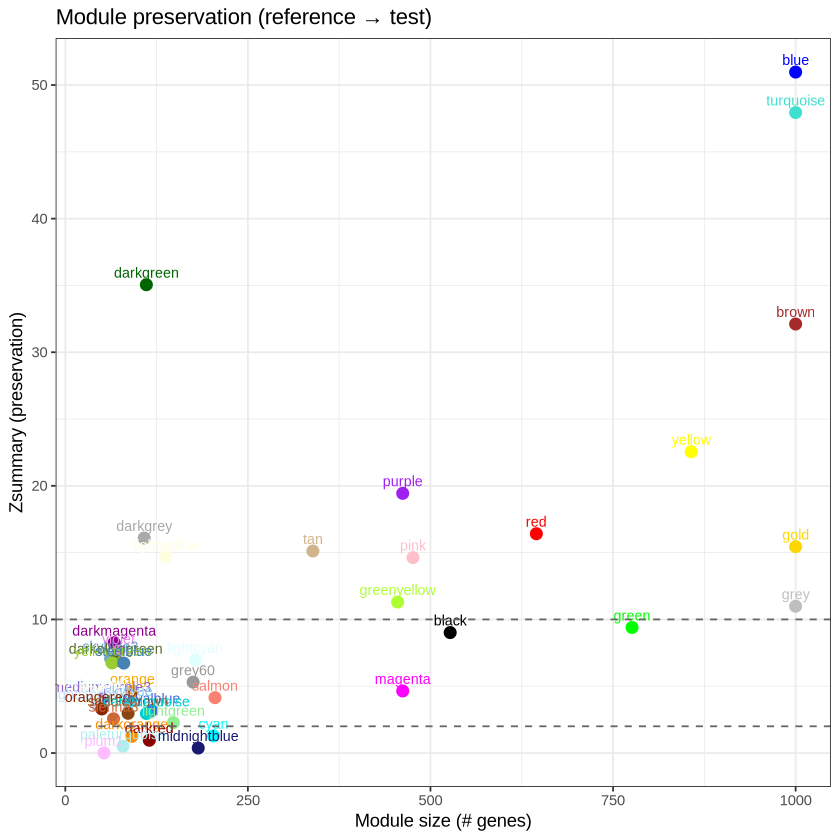

In [ ]:
ggplot(out, aes(x = size, y = Zsummary_pres, color = module, label = module)) +
  geom_point(size = 3) +
  geom_text(vjust = -0.7, size = 3, show.legend = FALSE) +
  geom_hline(yintercept = c(2, 10),
             linetype = "dashed",
             color = "grey40") +
  scale_color_identity() +
  labs(
    x = "Module size (# genes)",
    y = "Zsummary (preservation)",
    title = "Module preservation (reference → test)"
  ) +
  theme_bw()

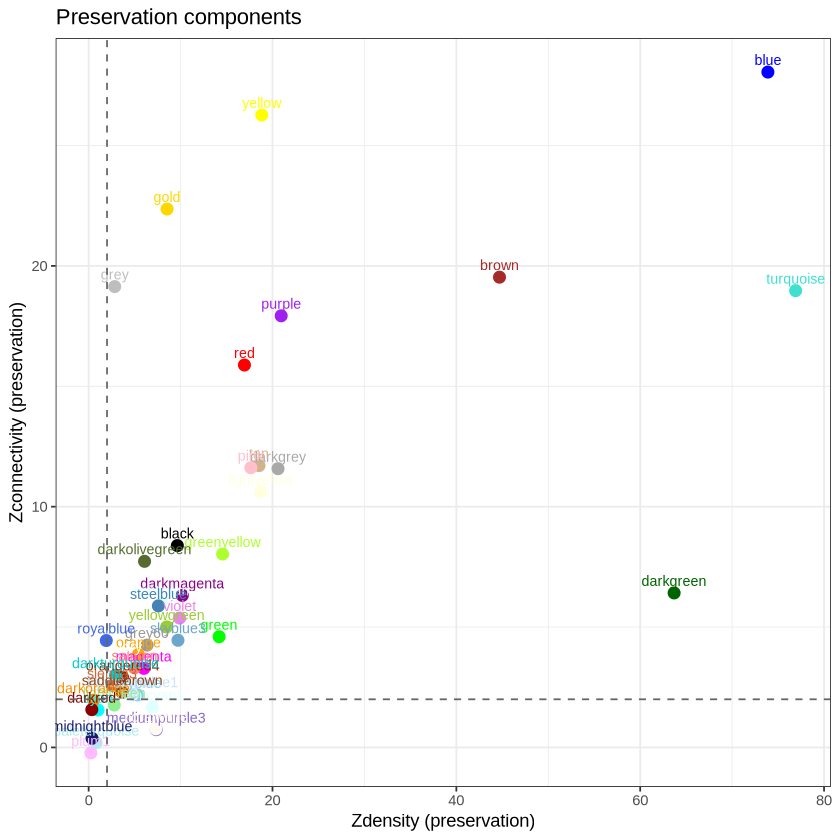

In [ ]:
ggplot(out, aes(x = Zdensity_pres, y = Zconnectivity_pres,
                color = module, label = module)) +
  geom_point(size = 3) +
  geom_text(vjust = -0.7, size = 3, show.legend = FALSE) +
  geom_vline(xintercept = 2,
             linetype = "dashed",
             color = "grey40") +
  geom_hline(yintercept = 2,
             linetype = "dashed",
             color = "grey40") +
  scale_color_identity() +
  labs(
    x = "Zdensity (preservation)",
    y = "Zconnectivity (preservation)",
    title = "Preservation components"
  ) +
  theme_bw()


In [ ]:
gene2mod_normal <- read.table("rna_tumor/module_membership_gene2module.tsv", header=TRUE, sep="\t", stringsAsFactors=FALSE)
refColors_map <- setNames(gene2mod_normal$module, gene2mod_normal$gene)
refColors <- refColors_map[commonGenes]

In [ ]:
multiExpr <- list(
  Ref= list(data = datExpr_normal),
  Test  = list(data = datExpr_tumor)
)

colorList <- list(Ref = refColors)

In [ ]:
# Do this only if intra_module_preservation_white_normal_vs_tumor.rds does not exist
if (!file.exists("intra_module_preservation_white_normal_vs_tumor.rds")){
    mp <- modulePreservation(
    multiExpr, colorList,
    referenceNetworks = 1,
    networkType = "signed",
    corFnc = "bicor",     # or "cor" if Pearson
    nPermutations = 200,
    randomSeed = 1,
    verbose = 3
)
saveRDS(mp, file="intra_module_preservation_white_normal_vs_tumor.rds")
} else {
    mp <- readRDS("intra_module_preservation_white_normal_vs_tumor.rds")
}

  ..checking data for excessive amounts of missing data..
     Flagging genes and samples with too many missing values...
      ..step 1
     Flagging genes and samples with too many missing values...
      ..step 1
  ..unassigned 'module' name: grey 
  ..all network sample 'module' name: gold
  ..calculating observed preservation values
  ..calculating permutation Z scores
 ..Working with set 1 as reference set
 ....working with set 2 as test set
  ......working on permutation 1
  ......working on permutation 2
  ......working on permutation 3
  ......working on permutation 4
  ......working on permutation 5
  ......working on permutation 6
  ......working on permutation 7
  ......working on permutation 8
  ......working on permutation 9
  ......working on permutation 10
  ......working on permutation 11
  ......working on permutation 12
  ......working on permutation 13
  ......working on permutation 14
  ......working on permutation 15
  ......working on permutation 16
  ......worki

In [ ]:
Ztab  <- mp$preservation$Z$ref.Ref$inColumnsAlsoPresentIn.Test
Ztab <- as.data.frame(Ztab)

In [ ]:
out <- data.frame(
  module = rownames(Ztab),
  size = Ztab$moduleSize,
  Zsummary_pres = Ztab$Zsummary.pres,
  Zdensity_pres = Ztab$Zdensity.pres,
  Zconnectivity_pres = Ztab$Zconnectivity.pres,
  stringsAsFactors = FALSE
)

out <- out[order(-out$Zsummary_pres), ]
head(out, 20)

,module,size,Zsummary_pres,Zdensity_pres,Zconnectivity_pres
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
2,blue,1000,136.13066,243.56870,28.69262001
45,yellow,857,120.52349,213.44231,27.60467680
3,brown,1000,72.01912,123.34789,20.69033784
42,turquoise,1000,68.01797,119.26206,16.77387893
30,pink,476,54.92512,98.19995,11.65028304
33,red,645,53.98920,93.28423,14.69417901
41,tan,339,43.72852,73.78420,13.67283473
24,magenta,462,42.13790,80.41392,3.86187523
6,darkgrey,108,40.27909,68.70233,11.85584946


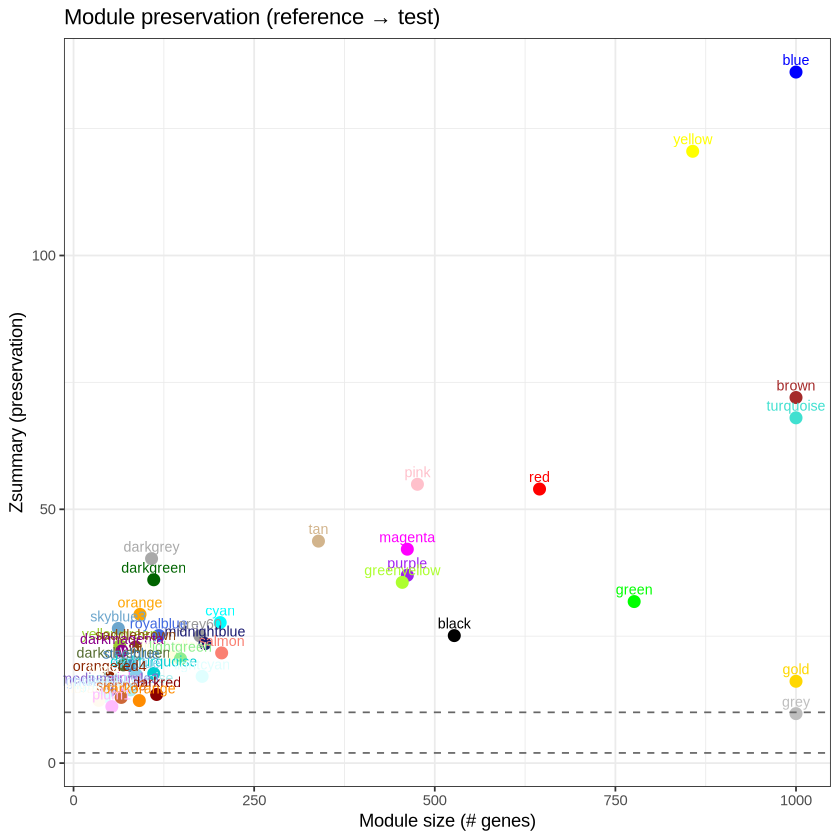

In [ ]:
ggplot(out, aes(x = size, y = Zsummary_pres, color = module, label = module)) +
  geom_point(size = 3) +
  geom_text(vjust = -0.7, size = 3, show.legend = FALSE) +
  geom_hline(yintercept = c(2, 10),
             linetype = "dashed",
             color = "grey40") +
  scale_color_identity() +
  labs(
    x = "Module size (# genes)",
    y = "Zsummary (preservation)",
    title = "Module preservation (reference → test)"
  ) +
  theme_bw()

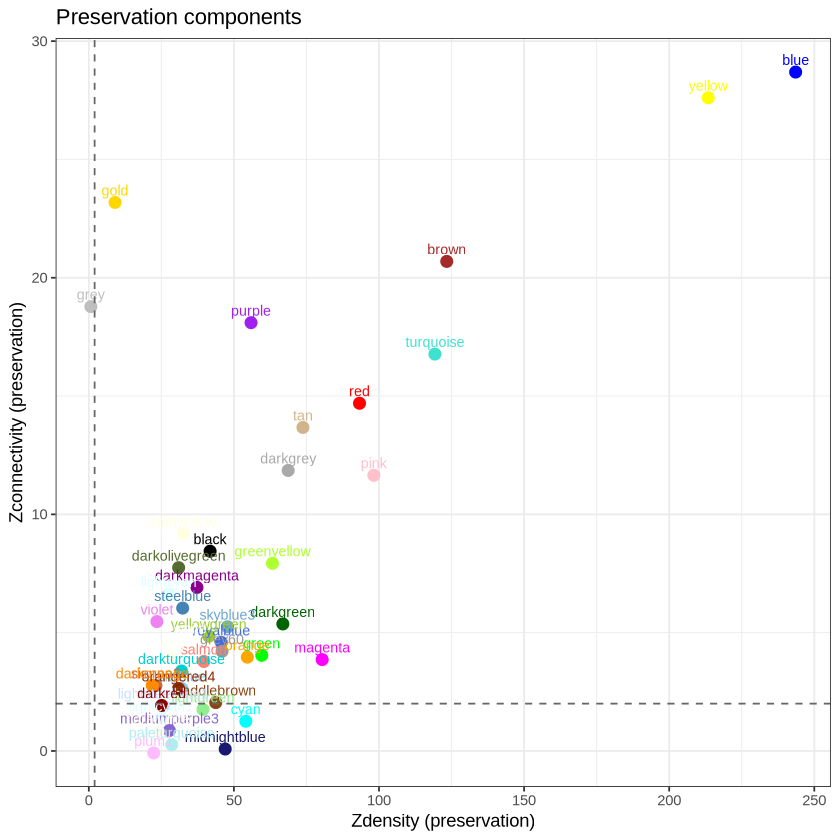

In [ ]:
ggplot(out, aes(x = Zdensity_pres, y = Zconnectivity_pres,
                color = module, label = module)) +
  geom_point(size = 3) +
  geom_text(vjust = -0.7, size = 3, show.legend = FALSE) +
  geom_vline(xintercept = 2,
             linetype = "dashed",
             color = "grey40") +
  geom_hline(yintercept = 2,
             linetype = "dashed",
             color = "grey40") +
  scale_color_identity() +
  labs(
    x = "Zdensity (preservation)",
    y = "Zconnectivity (preservation)",
    title = "Preservation components"
  ) +
  theme_bw()
